# EDA - Problem 1: Player Role Classification

Exploratory data analysis and diagnostic notebook for the Clash of Clans role classification dataset.

The dataset is expected at `data/processed/role_classification.parquet` and contains one row per player-clan relationship.

## 1. Setup and Data Loading

The necessary libraries are imported and the dataset is loaded from Parquet. Basic integrity and data types are verified.

In [1]:
# === 1. Setup and Data Loading ===
import warnings
warnings.filterwarnings('ignore')

%pip install pyarrow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_classif
from pathlib import Path
from collections import defaultdict

sns.set_theme(style="whitegrid", palette="viridis")
%matplotlib inline

# Resolve the dataset path from the current working directory or its parents
def find_project_root() -> Path:
    """Searches for the project root by checking the existence of the parquet file."""
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for cand in candidates:
        if (cand / 'data' / 'datasets' / 'role_classification.parquet').exists():
            return cand
    raise FileNotFoundError(
        "Could not find data/datasets/role_classification.parquet. "
        "Adjust the path or run the notebook from the project root."
    )

root = find_project_root()
DATA_PATH = root / 'data' / 'datasets' / 'role_classification.parquet'
print(f"Project root directory: {root}")
print(f"Dataset: {DATA_PATH}")

# Load the dataset
df = pd.read_parquet(DATA_PATH)
print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Project root directory: c:\Users\Usuario\Desktop\Clash of Clans ML Lab
Dataset: c:\Users\Usuario\Desktop\Clash of Clans ML Lab\data\datasets\role_classification.parquet
Dataset loaded with 837411 rows and 66 columns.


,player_tag,clan_tag,trophies_diff_from_clan_mean,trophies_ratio_to_clan_mean,exp_level_diff_from_clan_mean,exp_level_ratio_to_clan_mean,town_hall_level_diff_from_clan_mean,town_hall_level_ratio_to_clan_mean,war_stars_diff_from_clan_mean,war_stars_ratio_to_clan_mean,...,hero_mean_completion_ratio,spell_count,spell_mean_level,spell_mean_completion_ratio,equipment_count,equipment_mean_level,equipment_mean_completion_ratio,achievement_count,achievement_completion_ratio,role
0,#Y8GGPRUPR,#200022JVL,930.163265,4.231566,48.571429,1.219355,0.142857,1.008,1235.020408,1.550125,...,0.977473,18.0,6.166667,0.835504,36.0,20.833333,0.993827,53.0,10.612056,member
1,#9PQV8JPCP,#200022JVL,757.163265,3.630530,27.571429,1.124516,0.142857,1.008,1274.020408,1.567498,...,0.978571,17.0,7.176471,0.957049,39.0,19.692308,0.934473,53.0,11.132148,admin
2,#P8RLQVJL,#200022JVL,571.163265,2.984331,69.571429,1.314194,0.142857,1.008,4128.020408,2.838779,...,1.000000,18.0,6.833333,0.913360,42.0,20.285714,0.941799,53.0,15.574746,admin
3,#2VU80892Y,#200022JVL,386.163265,2.341605,44.571429,1.201290,0.142857,1.008,1210.020408,1.538989,...,0.973872,18.0,5.277778,0.713745,36.0,19.472222,0.937243,53.0,8.975956,coLeader
4,#98CPPQYUC,#200022JVL,-175.836735,0.389109,28.571429,1.129032,0.142857,1.008,372.020408,1.165712,...,0.995455,18.0,6.277778,0.843059,41.0,18.195122,0.859982,53.0,6.261092,admin


In [2]:
# General integrity information
print("=== General information ===")
df.info(show_counts=True)

print("\n=== Data types ===")
display(df.dtypes.to_frame(name='dtype'))

=== General information ===
<class 'pandas.DataFrame'>
RangeIndex: 837411 entries, 0 to 837410
Data columns (total 66 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   player_tag                                 837411 non-null  str    
 1   clan_tag                                   837411 non-null  str    
 2   trophies_diff_from_clan_mean               837411 non-null  float64
 3   trophies_ratio_to_clan_mean                837411 non-null  float64
 4   exp_level_diff_from_clan_mean              837411 non-null  float64
 5   exp_level_ratio_to_clan_mean               837411 non-null  float64
 6   town_hall_level_diff_from_clan_mean        837411 non-null  float64
 7   town_hall_level_ratio_to_clan_mean         837411 non-null  float64
 8   war_stars_diff_from_clan_mean              837411 non-null  float64
 9   war_stars_ratio_to_clan_mean               837411 non-null  floa

,dtype
player_tag,str
clan_tag,str
trophies_diff_from_clan_mean,float64
trophies_ratio_to_clan_mean,float64
exp_level_diff_from_clan_mean,float64
...,...
equipment_mean_level,float64
equipment_mean_completion_ratio,float64
achievement_count,float64
achievement_completion_ratio,float64


## 2. Basic Dataset Audit

Exact dimensions, data types, missing values, duplicates, and nearly constant features are checked.

In [3]:
# === 2. Basic Dataset Audit ===
print("Exact dimensions:")
print(f"  - Rows: {df.shape[0]}")
print(f"  - Columns: {df.shape[1]}")

# Missing values
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'missing': missing, 'percentage': missing_pct})
print("\nMissing values by column (only columns with missing values):")
display(missing_df[missing_df['missing'] > 0].sort_values('percentage', ascending=False))

# Exact duplicate rows
dup_rows = df.duplicated().sum()
print(f"\nExact duplicate rows: {dup_rows}")

# Nearly constant features
threshold = 0.95
constant_features = []
for col in df.columns:
    value_counts = df[col].value_counts(dropna=False)
    top_freq = value_counts.iloc[0] / len(df) if len(value_counts) > 0 else 1.0
    if top_freq >= threshold:
        constant_features.append((col, 'nearly_constant', top_freq))
    if pd.api.types.is_numeric_dtype(df[col]) and df[col].nunique(dropna=True) <= 1:
        constant_features.append((col, 'zero_variance', top_freq))

if constant_features:
    print("\nFeatures with a single value or nearly constant (>=95% single value):")
    display(pd.DataFrame(constant_features, columns=['column', 'type', 'mode_frequency']))
else:
    print("\nNo nearly constant features exceeding 95% of a single value were detected.")

Exact dimensions:
  - Rows: 837411
  - Columns: 66

Missing values by column (only columns with missing values):


,missing,percentage



Exact duplicate rows: 0

Features with a single value or nearly constant (>=95% single value):


,column,type,mode_frequency
0,capital_contributions_diff_from_clan_mean,nearly_constant,1.000000
1,capital_contributions_diff_from_clan_mean,zero_variance,1.000000
2,capital_contributions_ratio_to_clan_mean,nearly_constant,1.000000
3,capital_contributions_ratio_to_clan_mean,zero_variance,1.000000
4,attack_wins_ratio_to_clan_mean,nearly_constant,0.977350
5,defense_wins_ratio_to_clan_mean,nearly_constant,0.961056
6,attack_wins,nearly_constant,0.977350
7,defense_wins,nearly_constant,0.961056
8,combat_activity_total,nearly_constant,0.956284
9,achievement_count,nearly_constant,1.000000


## 3. Target Analysis (`role`)

The distribution of the target variable is analyzed and class imbalance is diagnosed.

Target distribution:


,count,percentage
role,,
member,346329,41.357111
admin,236271,28.214461
coLeader,202902,24.229679
leader,51909,6.198748


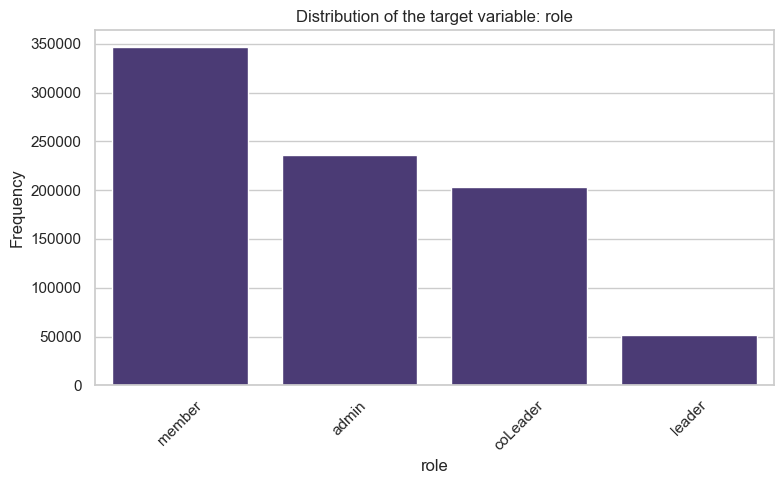


Class imbalance diagnostics:
- Relatively balanced distribution; accuracy/macro-F1 can be monitored.


In [4]:
TARGET = 'role'

# Absolute and percentage counts
target_counts = df[TARGET].value_counts(dropna=False)
target_pct = df[TARGET].value_counts(dropna=False, normalize=True) * 100
target_summary = pd.DataFrame({
    'count': target_counts,
    'percentage': target_pct
})
print("Target distribution:")
display(target_summary)

# Bar plot
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=TARGET, order=target_counts.index)
plt.title(f'Distribution of the target variable: {TARGET}')
plt.xlabel(TARGET)
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Class imbalance diagnostics
print("\nClass imbalance diagnostics:")
max_pct = target_pct.max()
min_pct = target_pct.min()
if max_pct > 60:
    print("- High imbalance: the majority class exceeds 60%.")
    print("- Consider class_weight='balanced', SMOTE, or choose metrics such as F1-macro / PR-AUC instead of accuracy.")
elif max_pct > 45:
    print("- Moderate imbalance: evaluate metric impact and consider robust stratification.")
else:
    print("- Relatively balanced distribution; accuracy/macro-F1 can be monitored.")

## 4. Functional Feature Analysis

Conceptual grouping of variables, skewness analysis, and distribution of critical variables.

Conceptual grouping of features:

Other:
  - player_tag
  - clan_tag
  - capital_contributions_diff_from_clan_mean
  - capital_contributions_ratio_to_clan_mean
  - clan_level
  - clan_points
  - clan_capital_points
  - members
  - war_frequency
  - war_league
  - capital_league
  - type
  - is_family_friendly
  - clan_capital_contributions
  - combat_activity_total
  - builder_progression_ratio
  - role

Clan/Competition Metrics:
  - trophies_diff_from_clan_mean
  - trophies_ratio_to_clan_mean
  - trophies_clan_pct
  - required_trophies
  - trophies
  - best_trophies
  - builder_base_trophies
  - best_builder_base_trophies
  - progression_ratio_trophies

Progression:
  - exp_level_diff_from_clan_mean
  - exp_level_ratio_to_clan_mean
  - town_hall_level_diff_from_clan_mean
  - town_hall_level_ratio_to_clan_mean
  - exp_level_clan_pct
  - town_hall_level
  - exp_level
  - builder_hall_level
  - troop_count
  - troop_mean_level
  - troop_mean_completion_ratio
  - hero_count
  - hero_mean_

,skewness,zero_pct,nan_pct
donation_ratio,883.319323,80.792108,0.0
donations,391.451305,73.318478,0.0
donations_diff_from_clan_mean,365.867788,30.106602,0.0
donation_balance,349.795288,65.915900,0.0
donations_received,151.429835,73.068063,0.0
donations_received_diff_from_clan_mean,79.421448,29.644105,0.0
attack_wins,35.560693,97.735043,0.0
combat_activity_total,34.937844,95.628431,0.0
attack_wins_diff_from_clan_mean,28.944551,71.602714,0.0
defense_wins,14.548574,96.105616,0.0


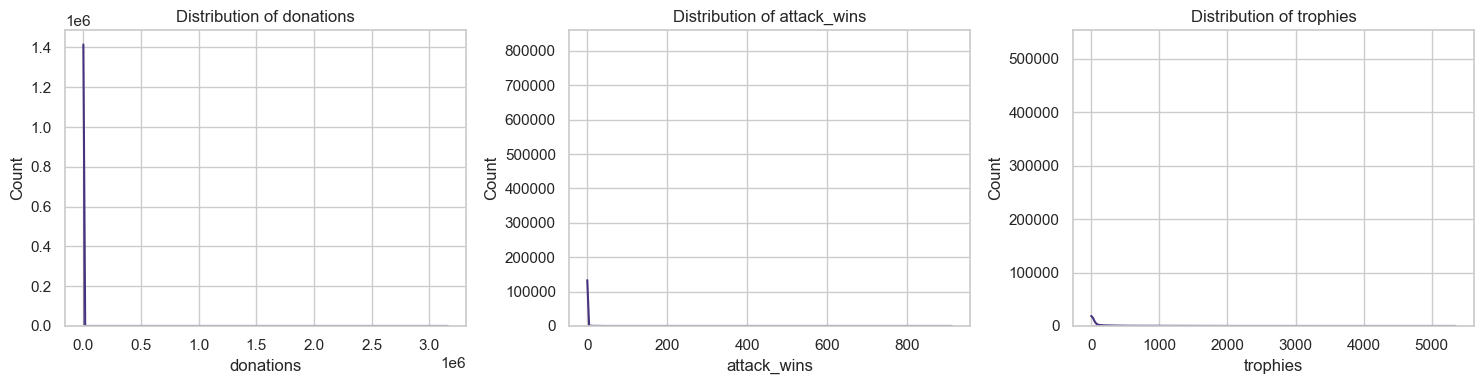

In [5]:
# === 4. Functional Feature Analysis ===

def conceptual_group(col: str) -> str:
    """Assigns a column to a conceptual group based on its name."""
    col_l = col.lower()
    if any(k in col_l for k in ['troop', 'hero', 'spell', 'equipment', 'builder_hall', 'town_hall', 'exp_level', 'achievement']):
        return 'Progression'
    if any(k in col_l for k in ['donat', 'attack', 'defense', 'war_stars', 'versus_battle']):
        return 'Activity'
    if any(k in col_l for k in ['loot', 'gold', 'elixir', 'dark_elixir', 'clan_games']):
        return 'Economy'
    if any(k in col_l for k in ['troph', 'clan_rank', 'war_win', 'clan_war_league', 'legend']):
        return 'Clan/Competition Metrics'
    return 'Other'

group_to_cols = defaultdict(list)
for col in df.columns:
    group_to_cols[conceptual_group(col)].append(col)

print("Conceptual grouping of features:")
for grp, cols in group_to_cols.items():
    print(f"\n{grp}:")
    for c in cols:
        print(f"  - {c}")

# Numeric variables excluding the target
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET in numeric_cols:
    numeric_cols.remove(TARGET)

# Skewness, percentage of zeros, and percentage of NaN
skew_df = pd.DataFrame({
    'skewness': df[numeric_cols].skew(),
    'zero_pct': (df[numeric_cols] == 0).mean() * 100,
    'nan_pct': df[numeric_cols].isna().mean() * 100
}).sort_values('skewness', key=lambda s: s.abs(), ascending=False)

print("\nSkewness and presence of zeros/NaN in numeric variables:")
display(skew_df)

# Visualization of critical distributions
critical_vars = ['donations', 'attack_wins', 'trophies']
present_critical = [v for v in critical_vars if v in df.columns]
if present_critical:
    fig, axes = plt.subplots(1, len(present_critical), figsize=(5 * len(present_critical), 4))
    if len(present_critical) == 1:
        axes = [axes]
    for ax, var in zip(axes, present_critical):
        sns.histplot(data=df, x=var, kde=True, ax=ax)
        ax.set_title(f'Distribution of {var}')
    plt.tight_layout()
    plt.show()
else:
    print("Expected critical variables (donations, attack_wins, trophies) were not found.")

## 5. Feature–Target Relationship

Class separation is analyzed and nonlinear predictive power is estimated using Mutual Information and Kruskal-Wallis.

Nonlinear predictive power (Mutual Information) by numeric feature:


,feature,mutual_info
0,donations_diff_from_clan_mean,0.143917
1,donations_received_diff_from_clan_mean,0.130772
2,town_hall_level_ratio_to_clan_mean,0.114983
3,trophies_diff_from_clan_mean,0.105480
4,war_stars_diff_from_clan_mean,0.090231
5,war_stars_ratio_to_clan_mean,0.089187
6,exp_level_ratio_to_clan_mean,0.085726
7,exp_level_diff_from_clan_mean,0.085472
8,war_stars_clan_pct,0.085422
9,town_hall_level_diff_from_clan_mean,0.083063



Kruskal-Wallis test (numeric variables vs role):


,feature,kruskal_stat,p_value,p_bonferroni
0,trophies_diff_from_clan_mean,1924.813639,0.0,0.0
1,exp_level_diff_from_clan_mean,78440.927836,0.0,0.0
2,exp_level_ratio_to_clan_mean,77140.020501,0.0,0.0
3,town_hall_level_diff_from_clan_mean,71404.451990,0.0,0.0
4,war_stars_diff_from_clan_mean,73333.481528,0.0,0.0
5,town_hall_level_ratio_to_clan_mean,69302.030722,0.0,0.0
6,war_stars_ratio_to_clan_mean,101672.692785,0.0,0.0
7,donations_diff_from_clan_mean,36690.786953,0.0,0.0
8,attack_wins_diff_from_clan_mean,19159.129773,0.0,0.0
9,donations_ratio_to_clan_mean,43229.232092,0.0,0.0


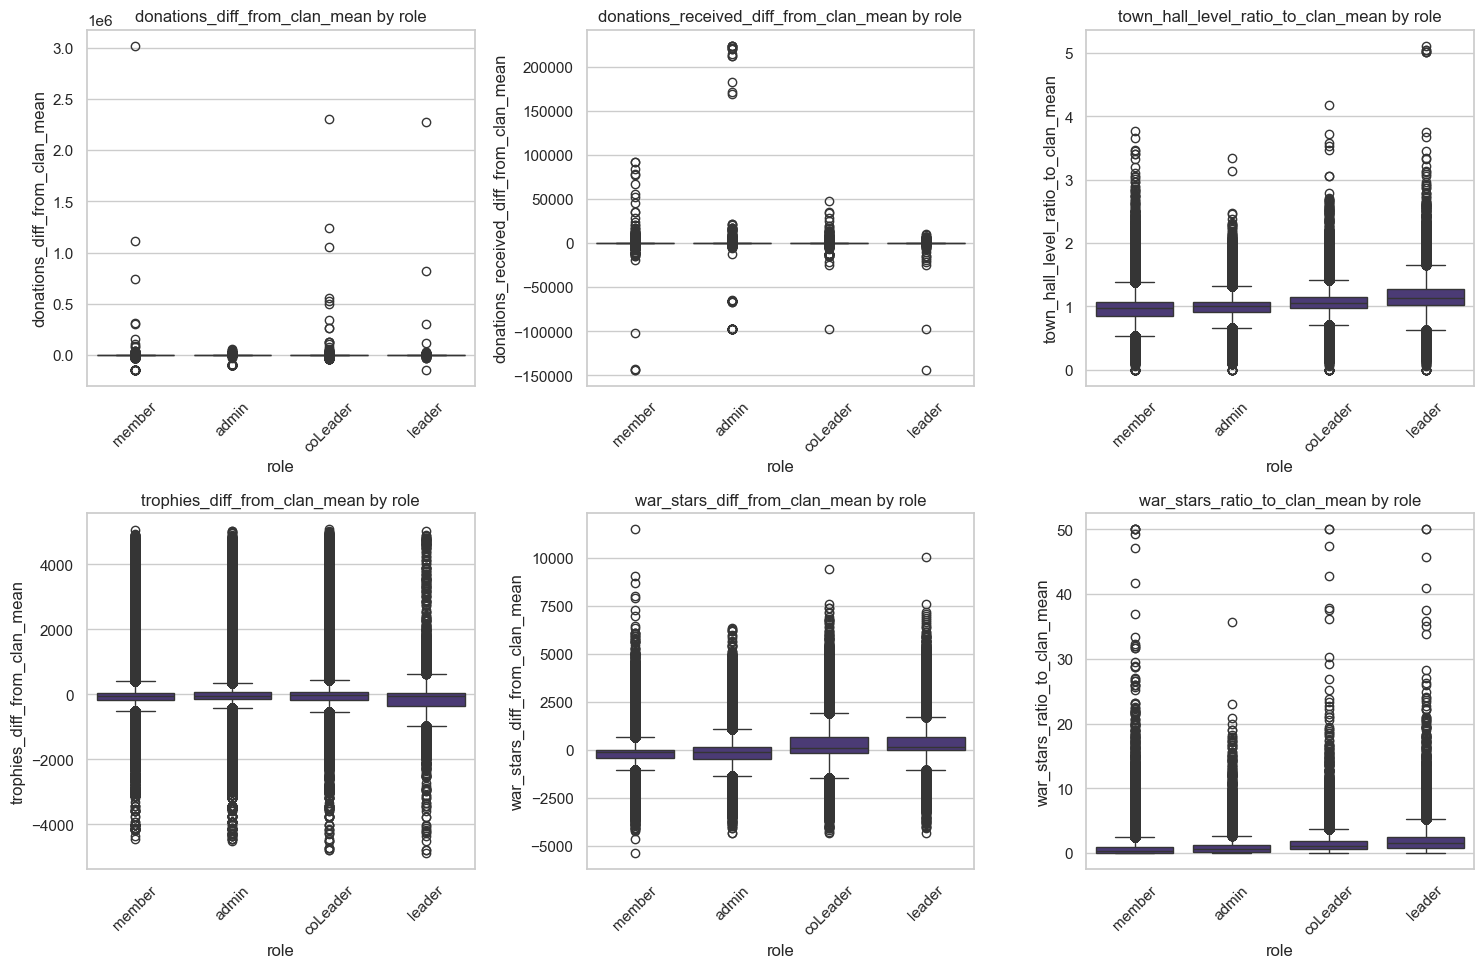

In [6]:
# === 5. Feature–Target Relationship ===

# Encode target for Mutual Information
target_encoded = pd.factorize(df[TARGET])[0]

# Prepare numerical data by temporarily imputing the median only for MI
df_num_for_mi = df[numeric_cols].copy()
for col in numeric_cols:
    if df_num_for_mi[col].isna().any():
        df_num_for_mi[col] = df_num_for_mi[col].fillna(df_num_for_mi[col].median())

# Mutual Information
mi_scores = mutual_info_classif(df_num_for_mi, target_encoded, random_state=42)
mi_df = pd.DataFrame({'feature': numeric_cols, 'mutual_info': mi_scores})
mi_df = mi_df.sort_values('mutual_info', ascending=False).reset_index(drop=True)
print("Nonlinear predictive power (Mutual Information) by numeric feature:")
display(mi_df.head(20))

# Kruskal-Wallis
kw_results = []
for col in numeric_cols:
    groups = []
    for role in df[TARGET].dropna().unique():
        group_vals = df.loc[df[TARGET] == role, col].dropna()
        if len(group_vals) > 5:
            groups.append(group_vals)
    if len(groups) >= 2:
        try:
            stat, p = stats.kruskal(*groups)
            kw_results.append((col, stat, p))
        except Exception:
            pass

kw_df = pd.DataFrame(kw_results, columns=['feature', 'kruskal_stat', 'p_value'])
kw_df['p_bonferroni'] = kw_df['p_value'] * len(numeric_cols)
kw_df = kw_df.sort_values('p_value').reset_index(drop=True)
print("\nKruskal-Wallis test (numeric variables vs role):")
display(kw_df.head(20))

# Boxplots of features with the highest Mutual Information
top_mi_features = mi_df.head(6)['feature'].tolist()
if top_mi_features:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    for ax, var in zip(axes, top_mi_features):
        sns.boxplot(data=df, x=TARGET, y=var, ax=ax)
        ax.set_title(f'{var} by {TARGET}')
        ax.set_xlabel(TARGET)
        ax.set_ylabel(var)
        plt.setp(ax.get_xticklabels(), rotation=45)
    # Hide empty axes if fewer than 6 features
    for ax in axes[len(top_mi_features):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No numeric features were found to plot.")

## 6. Multicollinearity and Redundancy

Pearson and Spearman correlation matrices are computed to identify pairs with |r| > 0.85.

Pairs with |Pearson| > 0.85:


,feature_1,feature_2,corr
0,exp_level_diff_from_clan_mean,exp_level_ratio_to_clan_mean,0.900149
1,exp_level_ratio_to_clan_mean,town_hall_level_ratio_to_clan_mean,0.859917
2,town_hall_level_diff_from_clan_mean,town_hall_level_ratio_to_clan_mean,0.964016
3,exp_level_diff_from_clan_mean,exp_level_clan_pct,0.894825
4,clan_points,clan_capital_points,0.891741
...,...,...,...
93,hero_mean_level,equipment_mean_completion_ratio,0.862480
94,hero_mean_completion_ratio,equipment_mean_completion_ratio,0.883966
95,equipment_count,equipment_mean_completion_ratio,0.901594
96,equipment_mean_level,equipment_mean_completion_ratio,0.997023



Pairs with |Spearman| > 0.85:


,feature_1,feature_2,corr
0,exp_level_diff_from_clan_mean,exp_level_ratio_to_clan_mean,0.971851
1,town_hall_level_diff_from_clan_mean,town_hall_level_ratio_to_clan_mean,0.993523
2,exp_level_diff_from_clan_mean,exp_level_clan_pct,0.933134
3,exp_level_ratio_to_clan_mean,exp_level_clan_pct,0.916646
4,war_stars_diff_from_clan_mean,war_stars_clan_pct,0.859458
...,...,...,...
127,spell_count,achievement_completion_ratio,0.930316
128,spell_mean_completion_ratio,achievement_completion_ratio,0.864668
129,equipment_count,achievement_completion_ratio,0.894912
130,equipment_mean_level,achievement_completion_ratio,0.895241


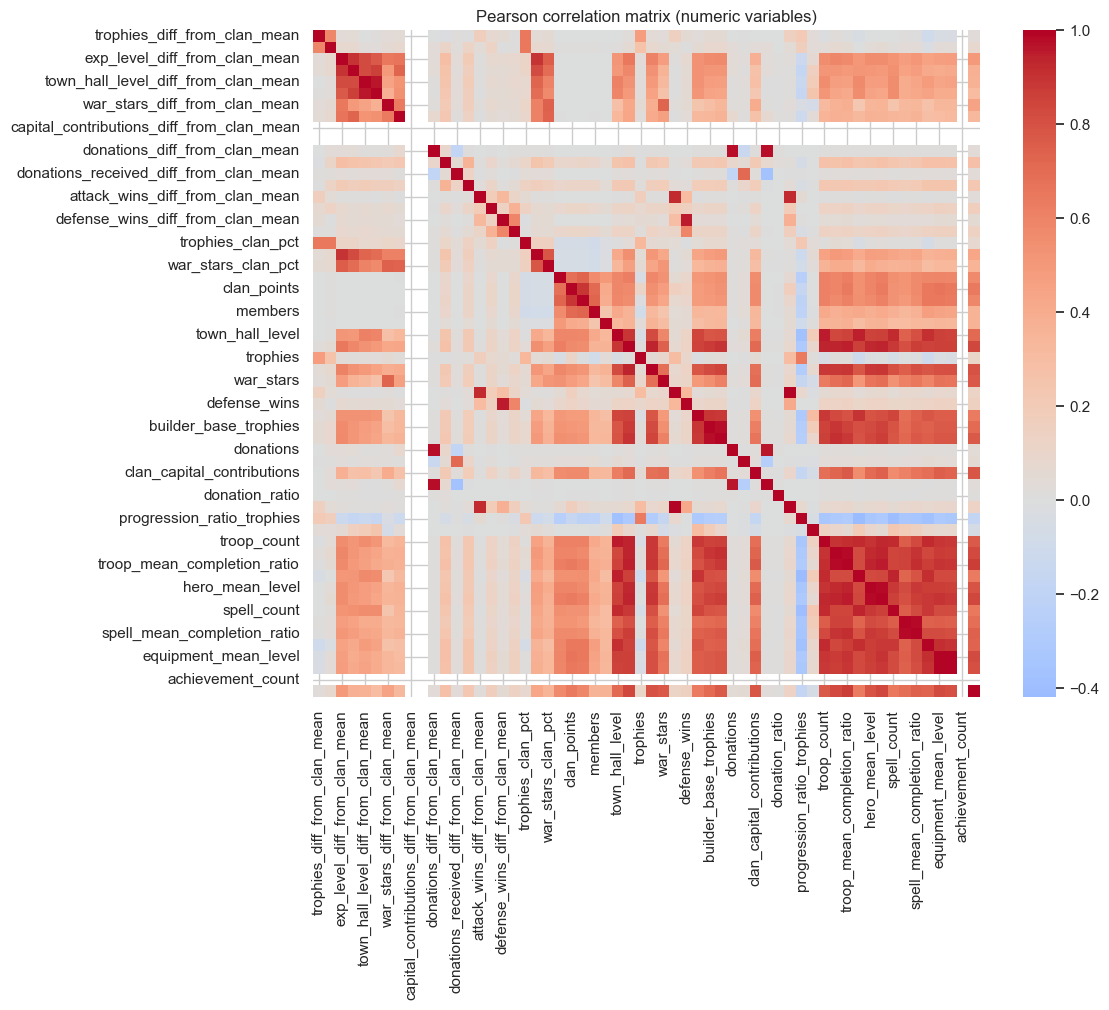

In [7]:
# === 6. Multicollinearity and Redundancy ===

df_corr = df[numeric_cols].copy()
df_corr = df_corr.replace([np.inf, -np.inf], np.nan)
for col in df_corr.columns:
    if df_corr[col].isna().any():
        df_corr[col] = df_corr[col].fillna(df_corr[col].median())

pearson_corr = df_corr.corr(method='pearson')
spearman_corr = df_corr.corr(method='spearman')

threshold_corr = 0.85

def get_high_corr_pairs(corr_matrix, threshold=threshold_corr):
    """Returns pairs of variables with correlation above the threshold (upper triangle)."""
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    pairs = []
    for col in upper.columns:
        for idx in upper.index:
            val = upper.loc[idx, col]
            if pd.notna(val) and abs(val) > threshold:
                pairs.append((idx, col, val))
    return pd.DataFrame(pairs, columns=['feature_1', 'feature_2', 'corr'])

pearson_pairs = get_high_corr_pairs(pearson_corr)
spearman_pairs = get_high_corr_pairs(spearman_corr)

print("Pairs with |Pearson| > 0.85:")
display(pearson_pairs if len(pearson_pairs) > 0 else None)

print("\nPairs with |Spearman| > 0.85:")
display(spearman_pairs if len(spearman_pairs) > 0 else None)

# Pearson correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pearson_corr, annot=False, cmap='coolwarm', center=0, square=True)
plt.title('Pearson correlation matrix (numeric variables)')
plt.tight_layout()
plt.show()

## 7. Outlier and Extreme Case Detection

Outliers are identified using the IQR rule and extreme examples are documented.

In [8]:
# === 7. Outlier and Extreme Case Detection ===

outlier_records = []
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    n_outliers = int(mask.sum())
    outlier_records.append({
        'feature': col,
        'q1': q1,
        'q3': q3,
        'IQR': iqr,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'n_outliers': n_outliers,
        'pct_outliers': 100.0 * n_outliers / len(df)
    })

outlier_df = pd.DataFrame(outlier_records).sort_values('n_outliers', ascending=False)
print("IQR outlier summary:")
display(outlier_df)

# Qualitative analysis for critical variables
for var in ['donations', 'trophies', 'attack_wins']:
    if var in df.columns:
        top_vals = df.nlargest(10, var)[[var, TARGET]].reset_index(drop=True)
        print(f"\nTop 10 extreme values of {var}:")
        display(top_vals)

IQR outlier summary:


,feature,q1,q3,IQR,lower_bound,upper_bound,n_outliers,pct_outliers
39,donation_balance,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,285424,34.084100
14,attack_wins_diff_from_clan_mean,-0.045455,0.000000e+00,4.545455e-02,-1.136364e-01,6.818182e-02,206706,24.683937
36,donations,0.000000,1.000000e+01,1.000000e+01,-1.500000e+01,2.500000e+01,202354,24.164240
11,donations_ratio_to_clan_mean,0.000000,9.341472e-02,9.341472e-02,-1.401221e-01,2.335368e-01,196591,23.476047
0,trophies_diff_from_clan_mean,-163.000000,5.809762e+01,2.210976e+02,-4.946464e+02,3.897440e+02,172131,20.555140
13,donations_received_ratio_to_clan_mean,0.000000,3.188769e-01,3.188769e-01,-4.783153e-01,7.971922e-01,169079,20.190683
12,donations_received_diff_from_clan_mean,-65.708333,0.000000e+00,6.570833e+01,-1.642708e+02,9.856250e+01,165152,19.721738
40,donation_ratio,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,160849,19.207892
16,defense_wins_diff_from_clan_mean,-0.172414,0.000000e+00,1.724138e-01,-4.310345e-01,2.586207e-01,159135,19.003213
37,donations_received,0.000000,4.550000e+01,4.550000e+01,-6.825000e+01,1.137500e+02,149080,17.802489



Top 10 extreme values of donations:


,donations,role
0,3161641.0,member
1,2400715.0,coLeader
2,2368337.0,leader
3,1266761.0,coLeader
4,1139948.0,member
5,1075534.0,coLeader
6,833804.0,leader
7,757437.0,member
8,573620.0,coLeader
9,535634.0,coLeader



Top 10 extreme values of trophies:


,trophies,role
0,5353.0,coLeader
1,5322.0,admin
2,5315.0,coLeader
3,5297.0,coLeader
4,5297.0,coLeader
5,5293.0,coLeader
6,5287.0,admin
7,5283.0,coLeader
8,5282.0,admin
9,5280.0,admin



Top 10 extreme values of attack_wins:


,attack_wins,role
0,913.0,coLeader
1,910.0,coLeader
2,910.0,admin
3,908.0,coLeader
4,907.0,admin
5,905.0,member
6,905.0,coLeader
7,902.0,member
8,902.0,coLeader
9,902.0,member


## 8. Modeling Implications (Conclusions for the Modeling Phase)

### Structured summary of findings and recommendations

In [9]:
# === Automatic executive summary ===
summary = {
    'n_rows': df.shape[0],
    'n_cols': df.shape[1],
    'missing_total': int(missing[missing > 0].sum()),
    'constant_features': [c[0] for c in constant_features],
    'target_distribution': target_counts.to_dict(),
    'target_imbalance_ratio': float(max_pct / max(min_pct, 1e-9)),
    'top_mi_features': mi_df.head(10).to_dict('records'),
    'pearson_high_corr_pairs': pearson_pairs.to_dict('records') if len(pearson_pairs) > 0 else [],
    'spearman_high_corr_pairs': spearman_pairs.to_dict('records') if len(spearman_pairs) > 0 else [],
    'outliers_max_pct': float(outlier_df['pct_outliers'].max()) if len(outlier_df) > 0 else 0.0,
    'outliers_most_common': outlier_df.head(1).to_dict('records') if len(outlier_df) > 0 else []
}

print("=== EXECUTIVE SUMMARY EDA P1 ===")
for k, v in summary.items():
    print(f"{k}: {v}")

=== EXECUTIVE SUMMARY EDA P1 ===
n_rows: 837411
n_cols: 66
missing_total: 0
constant_features: ['capital_contributions_diff_from_clan_mean', 'capital_contributions_diff_from_clan_mean', 'capital_contributions_ratio_to_clan_mean', 'capital_contributions_ratio_to_clan_mean', 'attack_wins_ratio_to_clan_mean', 'defense_wins_ratio_to_clan_mean', 'attack_wins', 'defense_wins', 'combat_activity_total', 'achievement_count', 'achievement_count']
target_distribution: {'member': 346329, 'admin': 236271, 'coLeader': 202902, 'leader': 51909}
target_imbalance_ratio: 6.671848812344679
top_mi_features: [{'feature': 'donations_diff_from_clan_mean', 'mutual_info': 0.1439169472014976}, {'feature': 'donations_received_diff_from_clan_mean', 'mutual_info': 0.13077239221819248}, {'feature': 'town_hall_level_ratio_to_clan_mean', 'mutual_info': 0.11498305556848232}, {'feature': 'trophies_diff_from_clan_mean', 'mutual_info': 0.10547974285196071}, {'feature': 'war_stars_diff_from_clan_mean', 'mutual_info': 0.090

### Preprocessing Pipeline

- **Imputation**  
  - Numeric variables: use the median if skewness is high or the percentage of outliers is large; otherwise, use the mean.  
  - Categorical variables: use the mode.  
  - If more than 40–50% of values in a column are missing, consider dropping it or creating an explicit `"missing"` category.

- **Transformations**  
  - Apply `log1p` to features with severe skewness (`|skew| > 1`) and presence of very high values, such as `donations`, `trophies`, or loot-related metrics.  
  - Use `RobustScaler` for variables with extreme outliers; `StandardScaler` for the rest.  
  - Encode the `role` target with `LabelEncoder` (or `OrdinalEncoder` if preserving semantic order is preferred).

### Validation Strategy

- Use **`StratifiedKFold`** with 5 or 10 folds to preserve class distribution in each partition.  
- For highly imbalanced datasets, avoid relying on `accuracy`. Prioritize:  
  - `F1-macro`  
  - `Cohen's Kappa`  
  - `PR-AUC` (for multiclass problems, use `average='macro'` or One-vs-Rest).  
  - Row-normalized confusion matrix.

### Feature Pruning

- Remove **zero variance** or **nearly constant** features (top frequency ≥ 95%).  
- Remove one feature from each pair with `|Pearson| > 0.85` or `|Spearman| > 0.85`, keeping the one with higher mutual information or interpretability.  
- Review outlier concentration: if `pct_outliers` is very high (>10–15%), consider treating that variable with a robust transformation instead of removing records.

### Recommended Baseline

1. **Multiclass Logistic Regression**  
   - `LogisticRegression(multi_class='multinomial', solver='saga', class_weight='balanced', max_iter=1000)`  
   - A good choice as a fast and interpretable baseline.  

2. **Random Forest**  
   - Robust to nonlinearities and outliers; use `class_weight='balanced_subsample'`.  
   - Evaluate feature importance as a complement to MI analysis.

3. **Gradient Boosting / XGBoost / LightGBM**  
   - More powerful models if the dataset is large; use `scale_pos_weight` or `class_weight` for imbalance and hyperparameter search with nested cross-validation.

These conclusions should directly feed the feature engineering and modeling phase of Problem 1.